# YOLO + ClearML + TensorBoard + Optuna pipeline
# Dataset: Roboflow Valentines Chocolates v4 (YOLOv8 format)

In [22]:

# =========================
# 2. Imports
# =========================
from clearml import Task
from ultralytics import YOLO
from roboflow import Roboflow
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import cv2
import os
import glob
import optuna
import optunahub
from optuna.integration.tensorboard import TensorBoardCallback


In [23]:
# =========================
# 3. Init ClearML Task
# =========================
task = Task.init(project_name="YOLO-Roboflow", task_name="Valentines-Chocolates")


In [24]:
logger = task.get_logger()
print("ClearML Task ID:", task.id)

ClearML Task ID: b349410a63154790b5c12274cedb579e


In [25]:

DATA_DIR = Path("../data/Valentines Chocolates.v4-fixed-annotations.yolov8").resolve()
IMAGES_TRAIN = DATA_DIR / "train" / "images"
LABELS_TRAIN = DATA_DIR / "train" / "labels"

jpg_count = len(list(IMAGES_TRAIN.glob("*.jpg")))
print(f"Train images: {jpg_count}")

# Классы из data.yaml
CLASS_NAMES = [
    "Dark Almond Nougat", "Dark Almonds", "Dark Bordeaux", "Dark Caramel Patties",
    "Dark Chocolate Buttercream", "Dark Marzipan", "Dark Normandie", "Dark Scotchmallow",
    "Dark Walnut Square", "Milk Almond Caramel", "Milk Almonds", "Milk Beverly",
    "Milk Bordeaux", "Milk Butterscotch Square", "Milk California Brittle", "Milk Chelsea",
    "Milk Chocolate Buttercream", "Milk Coconut Cream", "Milk Mayfair", "Milk Mocha",
    "Milk Molasses Chips", "Milk Rum Nougat",
]

YAML_DEMO = DATA_DIR / "data.yaml"
YAML_DEMO.write_text(
    f"path: {DATA_DIR}\n"
    "train: train/images\n"
    "val:   train/images\n"
    f"nc: {len(CLASS_NAMES)}\n"
    f"names: {CLASS_NAMES}\n"
)
print("data.yaml →", YAML_DEMO)




Train images: 225
data.yaml → /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/data.yaml


Showing training samples:


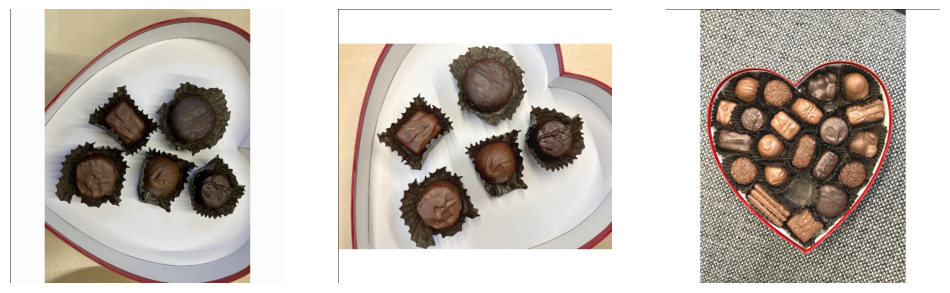

In [26]:

# =========================
# 5. Show sample images
# =========================
def show_samples(image_dir, n=3):
    images = glob.glob(os.path.join(image_dir, "*.jpg"))[:n]

    plt.figure(figsize=(12, 6))
    for i, img_path in enumerate(images):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # show locally
        plt.subplot(1, n, i+1)
        plt.imshow(img_rgb)
        plt.axis("off")

        # log to ClearML
        logger.report_image(
            title="dataset",
            series="samples",
            iteration=i,
            image=img_rgb
        )
    plt.show()

print("Showing training samples:")
show_samples(IMAGES_TRAIN)




In [ ]:

# =========================
# 6. Define Optuna objective
# =========================
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    batch = trial.suggest_categorical("batch", [8, 16])

    model = YOLO("yolov8n.pt")

    yolo_hparams = {
        "epochs": 5,  # Для демо HPO ставим мало, в реальности больше [8]
        "imgsz": 32,
        "batch": batch,
        "lr0": lr,
        "device": "1" if torch.cuda.is_available() else "cpu",
        "workers": 4,
        "project": "runs",
        "name": f"trial_{trial.number}",
        "verbose": False,
        "exist_ok": True,
    }

    task.connect(yolo_hparams, name=f"hparams_trial_{trial.number}")
    
    results = model.train(
        data=YAML_DEMO,
        plots=True,
        **yolo_hparams
    )

    # Extract metric (mAP50)
    metrics = results.results_dict
    score = metrics.get("metrics/mAP50(B)", 0)
    
    logger.report_scalar(
    title="optuna",
    series="mAP50",
    value=score,
    iteration=trial.number
    )

    return score


[I 2026-04-01 23:56:05,679] A new study created in memory with name: no-name-cde6b7cf-2496-4672-9f01-e0df35edac12
/tmp/ipykernel_415842/1564582325.py:7: ExperimentalWarning:

TensorBoardCallback is experimental (supported from v2.0.0). The interface can change in the future.



New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.10.20 torch-2.10.0 CUDA:1 (NVIDIA GeForce RTX 2080 Ti, 11012MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/data.yaml, epochs=5, time=None, patience=100, batch=8, imgsz=40, save=True, save_period=-1, cache=False, device=1, workers=4, project=runs, name=trial_0, exist_ok=True, pretrained=True, optimizer=auto, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=

train: Scanning /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/train/labels.cache... 225 images, 0 backgrounds, 0 corrupt: 100%|██████████| 225/225 [00:00<?, ?it/s]
val: Scanning /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/train/labels.cache... 225 images, 0 backgrounds, 0 corrupt: 100%|██████████| 225/225 [00:00<?, ?it/s]


Plotting labels to runs/trial_0/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=1.0285415275607332e-05' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000385, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 64 train, 64 val
Using 4 dataloader workers
Logging results to runs/trial_0
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/5      0.21G      5.156      5.233       1.83         22         64: 100%|██████████| 29/29 [00:05<00:00,  5.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:01<00:00, 14.98it/s]


...

                   all        225       3870          0          0          0          0


Speed: 0.0ms preprocess, 1.0ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to runs/trial_2


[I 2026-04-02 00:01:09,552] Trial 2 finished with value: 0.0 and parameters: {'lr': 5.6693529345582566e-05, 'batch': 8}. Best is trial 0 with value: 0.0.


Best params: {'lr': 1.0285415275607332e-05, 'batch': 8}


█████████████████████████████████ 100% | 5.91/5.91 MB [00:00<00:00, 48.99MB/s]: /home/lupasic/Programs/AIS/lectures/08/demo/.pixi/envs/default/lib/python3.10/site-packages/tqdm/std.py:636: TqdmWarning:

clamping frac to range [0, 1]

████████████████████████████████ 100% | 5.91/5.91 MB [00:00<-00:00,  7.27MB/s]: 


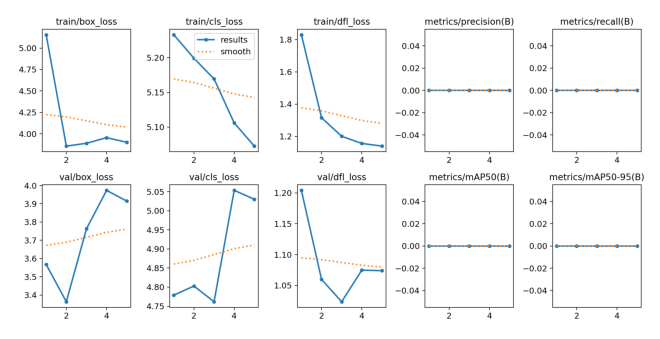

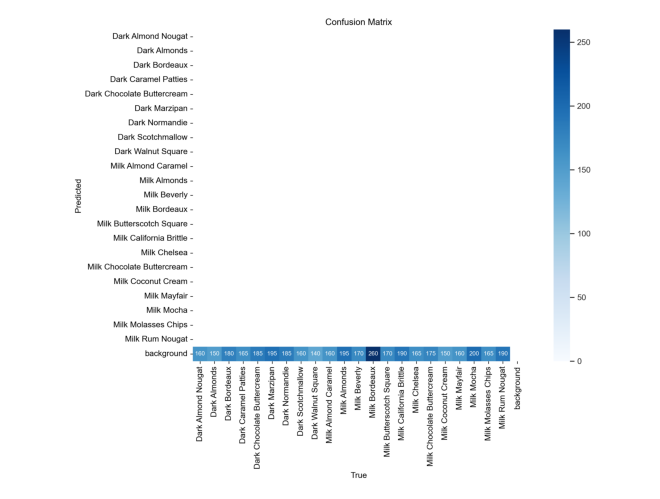

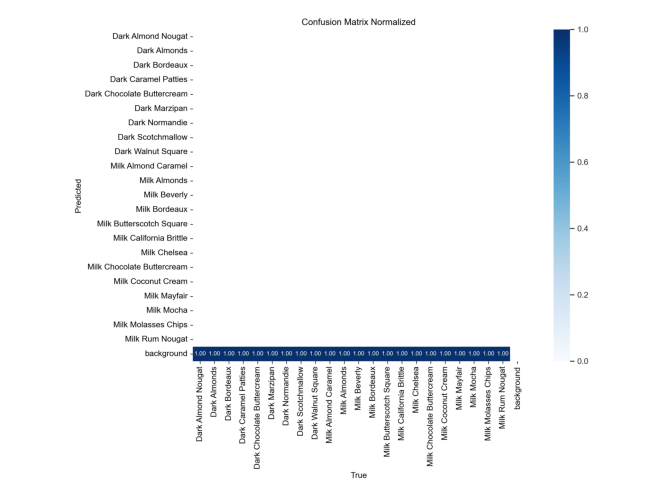

In [28]:

# =========================
# 7. Run Optuna study with TensorBoard logging
# =========================
# module = optunahub.load_module(package="samplers/auto_sampler")
# study = optuna.create_study(direction="maximize", sampler=module.AutoSampler())
study = optuna.create_study(direction="maximize")
tb_callback = TensorBoardCallback("runs/tb_logs", metric_name="mAP50")

study.optimize(objective, n_trials=3, callbacks=[tb_callback])

print("Best params:", study.best_params)


New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11012MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/data.yaml, epochs=30, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/train, name=final_model, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=F

train: Scanning /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/train/labels.cache... 225 images, 0 backgrounds, 0 corrupt: 100%|██████████| 225/225 [00:00<?, ?it/s]
val: Scanning /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/train/labels.cache... 225 images, 0 backgrounds, 0 corrupt: 100%|██████████| 225/225 [00:00<?, ?it/s]


Plotting labels to runs/train/final_model/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=1.0285415275607332e-05' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000385, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/train/final_model
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/30      1.84G      1.036       4.66      1.127         11        640: 100%|██████████| 29/29 [00:05<00:00,  5.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:01<00:00, 12.35it/s]

                   all        225       3870          0          0          0          0


...

                   all        225       3870      0.958      0.967      0.988      0.821

30 epochs completed in 0.108 hours.
Optimizer stripped from runs/train/final_model/weights/last.pt, 6.3MB
Optimizer stripped from runs/train/final_model/weights/best.pt, 6.3MB

Validating runs/train/final_model/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11012MiB)
Model summary (fused): 168 layers, 3,009,938 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:04<00:00,  3.06it/s]


                   all        225       3870      0.958      0.966      0.988      0.821
    Dark Almond Nougat        160        160      0.998      0.981      0.995       0.82
          Dark Almonds        130        150      0.986      0.957      0.992      0.805
         Dark Bordeaux        175        180      0.838      0.978      0.971      0.798
  Dark Caramel Patties        165        165       0.98          1      0.995      0.863
Dark Chocolate Buttercream        180        185      0.952      0.962      0.984      0.835
         Dark Marzipan        180        195       0.99      0.991      0.994      0.825
        Dark Normandie        185        185      0.921      0.935      0.976      0.789
     Dark Scotchmallow        160        160      0.987       0.95      0.991      0.845
    Dark Walnut Square        130        140      0.997      0.993      0.995       0.82
   Milk Almond Caramel        160        160      0.976      0.944      0.992      0.815
          Milk Al

NameError: name 'data_path' is not defined

                                            0% | 0.00/5.97 MB [00:00<?, ?MB/s]: /home/lupasic/Programs/AIS/lectures/08/demo/.pixi/envs/default/lib/python3.10/site-packages/tqdm/std.py:636: TqdmWarning:

clamping frac to range [0, 1]

████████████████████████████████ 100% | 5.97/5.97 MB [00:00<-00:00,  8.02MB/s]: 


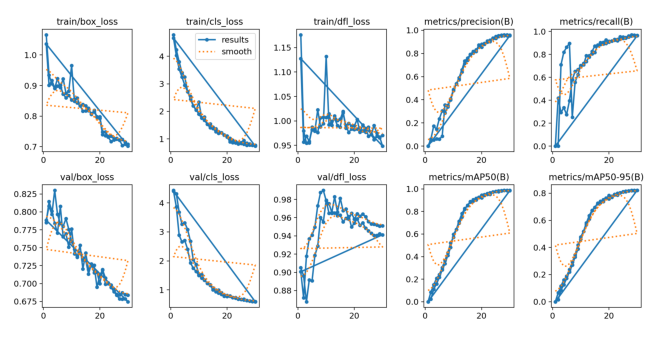

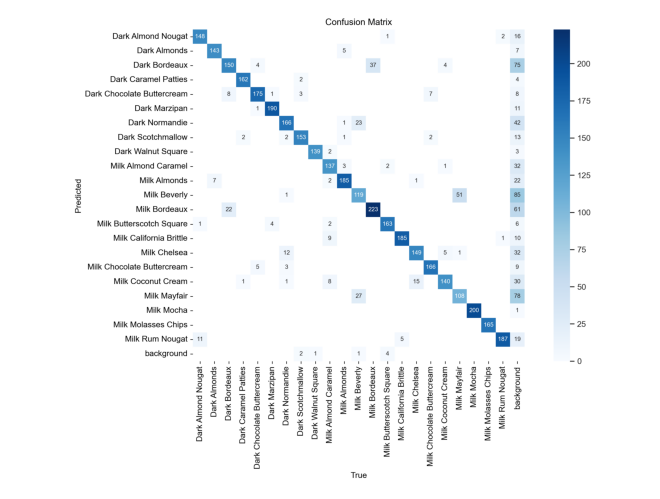

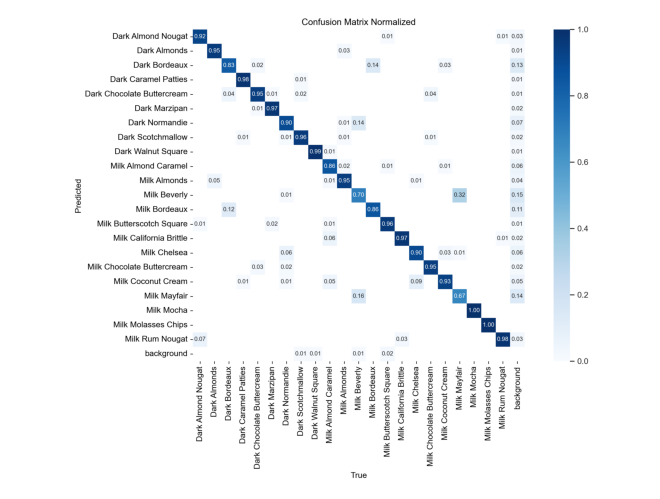

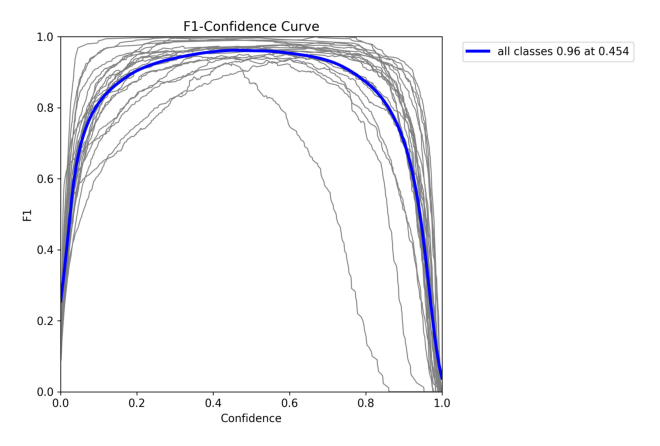

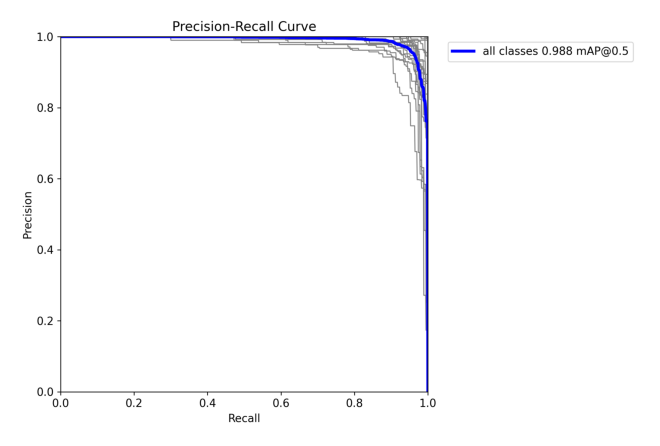

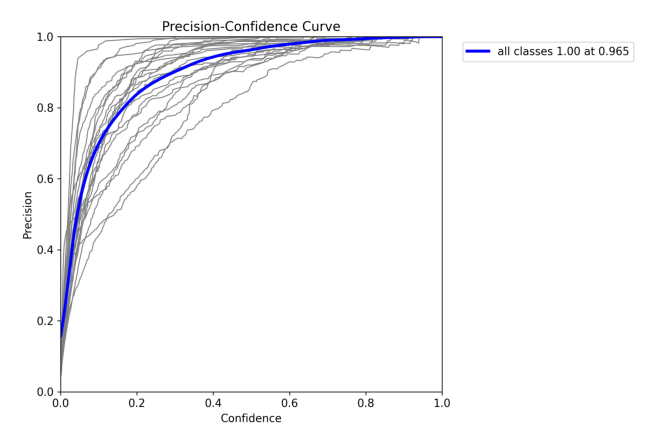

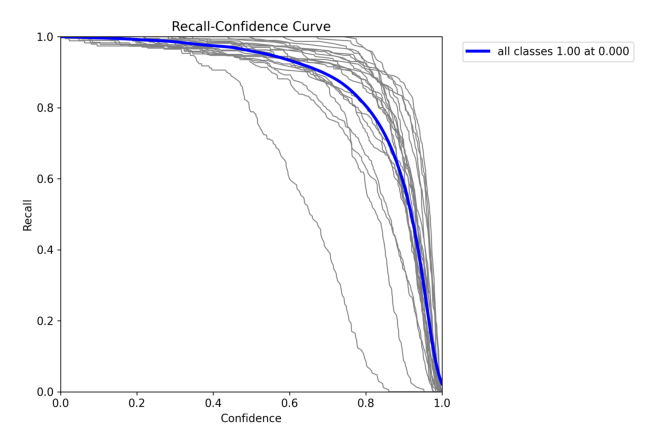

In [ ]:

# =========================
# 8. Train final model with best params
# =========================
best_params = study.best_params

model = YOLO("yolov8n.pt")
model.train(
    data=YAML_DEMO,
    epochs=30,
    batch=best_params["batch"],
    lr0=best_params["lr"],
    project="runs/train",
    name="final_model",
    exist_ok=True
)

# =========================
# 9. Inference on test images
# =========================
print("Running inference...")

image_paths = glob.glob(os.path.join(IMAGES_TEST, "*.jpg"))[:4]

for img_path in image_paths:
    results = model.predict(img_path, save=True)


Running inference...

image 1/1 /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/train/images/i.rf.49e72bfcfb48573387175cb6f5f985db.jpg: 640x640 1 Dark Caramel Patties, 1 Dark Chocolate Buttercream, 1 Dark Normandie, 1 Milk Almond Caramel, 1 Milk Chocolate Buttercream, 7.4ms
Speed: 2.5ms preprocess, 7.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


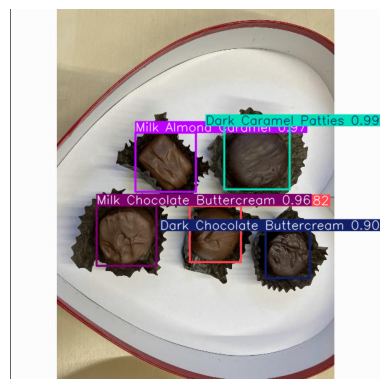


image 1/1 /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/train/images/i.rf.c5bcf30a67af87f204f9a39bea1d2c78.jpg: 640x640 1 Dark Caramel Patties, 1 Dark Chocolate Buttercream, 1 Dark Normandie, 1 Milk Almond Caramel, 1 Milk Chocolate Buttercream, 7.0ms
Speed: 2.2ms preprocess, 7.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


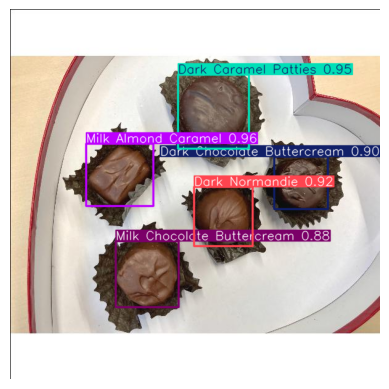


image 1/1 /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/train/images/i.rf.1ae03ac1edf51992c01fd20c92f04c6b.jpg: 640x640 1 Dark Almond Nougat, 1 Dark Almonds, 2 Dark Bordeauxs, 1 Dark Caramel Patties, 1 Dark Chocolate Buttercream, 1 Dark Marzipan, 2 Dark Normandies, 1 Dark Scotchmallow, 1 Milk Almond Caramel, 1 Milk Almonds, 1 Milk Beverly, 1 Milk Bordeaux, 1 Milk Butterscotch Square, 1 Milk California Brittle, 1 Milk Chelsea, 1 Milk Coconut Cream, 1 Milk Mayfair, 1 Milk Mocha, 1 Milk Molasses Chips, 1 Milk Rum Nougat, 7.2ms
Speed: 2.3ms preprocess, 7.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


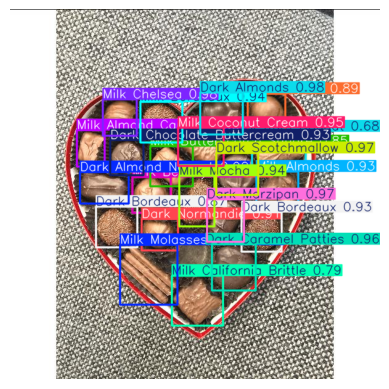


image 1/1 /home/lupasic/Programs/AIS/lectures/08/demo/data/Valentines Chocolates.v4-fixed-annotations.yolov8/train/images/i.rf.3520d63bf5ffe23e1e5770117f6f6cc5.jpg: 640x640 1 Dark Almond Nougat, 1 Dark Almonds, 1 Dark Bordeaux, 1 Dark Caramel Patties, 1 Dark Chocolate Buttercream, 2 Dark Marzipans, 1 Dark Normandie, 3 Dark Scotchmallows, 2 Dark Walnut Squares, 1 Milk Almond Caramel, 1 Milk Almonds, 1 Milk Beverly, 1 Milk Bordeaux, 1 Milk Butterscotch Square, 1 Milk California Brittle, 1 Milk Chelsea, 1 Milk Chocolate Buttercream, 1 Milk Coconut Cream, 1 Milk Mayfair, 1 Milk Mocha, 1 Milk Molasses Chips, 2 Milk Rum Nougats, 7.3ms
Speed: 2.3ms preprocess, 7.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


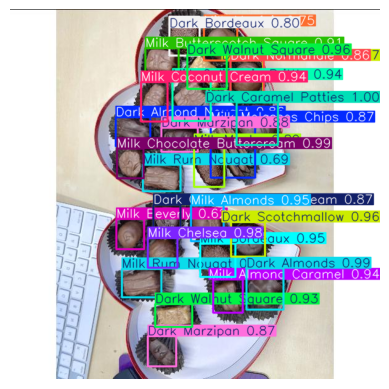

In [30]:

print("Running inference...")

image_paths = glob.glob(os.path.join(IMAGES_TRAIN, "*.jpg"))[:4]

for i, img_path in enumerate(image_paths):
    results = model.predict(img_path)

    # draw predictions
    pred_img = results[0].plot()

    # log to ClearML
    logger.report_image(
        title="inference",
        series="predictions",
        iteration=i,
        image=pred_img
    )

    # show locally
    plt.imshow(cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
    plt.close()

# =========================
# 10. Optional: log YOLO result plots
# =========================
plot_files = glob.glob("runs/train/final_model/*.png")

for i, p in enumerate(plot_files):
    img = cv2.imread(p)
    if img is None:
        continue

    logger.report_image(
        title="yolo_plots",
        series=os.path.basename(p),
        iteration=i,
        image=img
    )



In [31]:

# =========================
# 11. Close ClearML task
# =========================
task.close()

print("Pipeline completed.")


Pipeline completed.
